# A/B-тест кампании удержания

**Гипотеза:** скидка 15% на годовую подписку снижает churn
на 3 п.п. (с 26.5% до 23.5%).

**Дизайн:**
- Метрика: churn rate
- Baseline: 26.5%
- MDE: 3 п.п.
- α = 0.05
- Power = 0.80
- Тест: χ² для пропорций

**Что делаем:**
1. Считаем размер выборки.
2. Симулируем данные на историческом датасете.
3. Проверяем значимость.
4. Оцениваем бизнес-эффект.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from src.data.load import load_data

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
BASELINE_CHURN = 0.265
TARGET_CHURN = 0.235
MDE = BASELINE_CHURN - TARGET_CHURN
ALPHA = 0.05
POWER = 0.80

effect_size = proportion_effectsize(BASELINE_CHURN, TARGET_CHURN)
power_analysis = NormalIndPower()

n_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=ALPHA,
    power=POWER,
    ratio=1.0,
    alternative="two-sided",
)

print(f"Baseline churn:    {BASELINE_CHURN:.1%}")
print(f"Target churn:      {TARGET_CHURN:.1%}")
print(f"MDE:               {MDE:.1%}")
print(f"Effect size:       {effect_size:.4f}")
print(f"Sample per group:  {int(np.ceil(n_per_group)):,}")
print(f"Total sample:      {int(np.ceil(n_per_group * 2)):,}")

Baseline churn:    26.5%
Target churn:      23.5%
MDE:               3.0%
Effect size:       0.0693
Sample per group:  3,268
Total sample:      6,536


In [3]:
def simulate_experiment(n_control, n_treatment,
                        p_control=BASELINE_CHURN,
                        p_treatment=TARGET_CHURN,
                        seed=42):
    rng = np.random.default_rng(seed)

    control = rng.binomial(1, p_control, n_control)
    treatment = rng.binomial(1, p_treatment, n_treatment)

    return control, treatment


n_control = int(np.ceil(n_per_group))
n_treatment = n_control

control, treatment = simulate_experiment(n_control, n_treatment)

control_churn = control.mean()
treatment_churn = treatment.mean()
absolute_lift = control_churn - treatment_churn
relative_lift = absolute_lift / control_churn

print(f"Control churn:      {control_churn:.4f} (n={n_control:,})")
print(f"Treatment churn:    {treatment_churn:.4f} (n={n_treatment:,})")
print(f"Absolute lift:      {absolute_lift:+.4f}")
print(f"Relative lift:      {relative_lift:+.2%}")

Control churn:      0.2714 (n=3,268)
Treatment churn:    0.2203 (n=3,268)
Absolute lift:      +0.0511
Relative lift:      +18.83%


In [4]:
contingency = np.array([
    [control.sum(), len(control) - control.sum()],
    [treatment.sum(), len(treatment) - treatment.sum()],
])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Contingency table:")
print(f"                Churn    Retained")
print(f"Control         {control.sum():5d}    {len(control) - control.sum():5d}")
print(f"Treatment       {treatment.sum():5d}    {len(treatment) - treatment.sum():5d}")
print()
print(f"χ² statistic:   {chi2:.4f}")
print(f"p-value:        {p_value:.6f}")
print(f"Significant:    {'✅ YES' if p_value < ALPHA else '❌ NO'}")

Contingency table:
                Churn    Retained
Control           887     2381
Treatment         720     2548

χ² statistic:   22.7381
p-value:        0.000002
Significant:    ✅ YES


In [5]:
se = np.sqrt(
    control_churn * (1 - control_churn) / n_control
    + treatment_churn * (1 - treatment_churn) / n_treatment
)
z_crit = norm.ppf(1 - ALPHA / 2)

ci_lower = absolute_lift - z_crit * se
ci_upper = absolute_lift + z_crit * se

print(f"Absolute lift:  {absolute_lift:+.4f}")
print(f"95% CI:         [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"95% CI (п.п.):  [{ci_lower*100:+.2f}, {ci_upper*100:+.2f}]")

Absolute lift:  +0.0511
95% CI:         [+0.0303, +0.0719]
95% CI (п.п.):  [+3.03, +7.19]


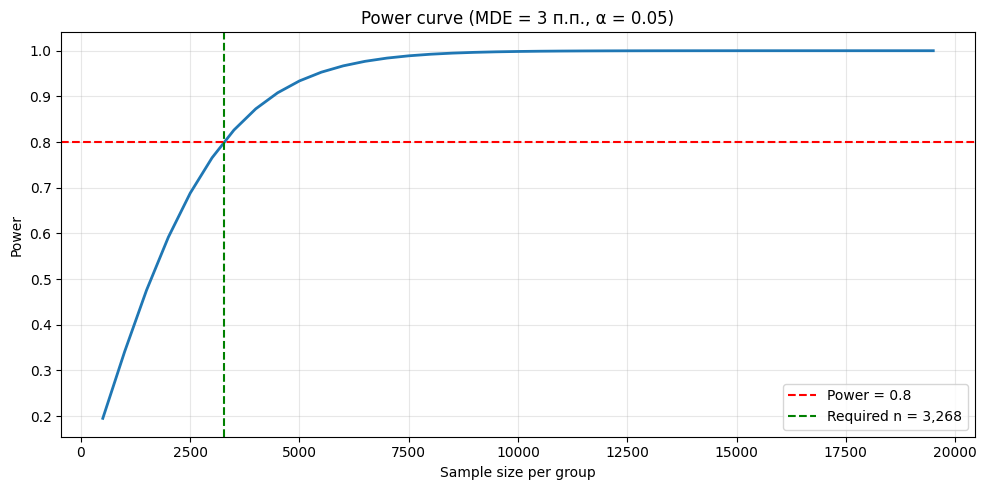

In [6]:
sample_sizes = np.arange(500, 20000, 500)
powers = [
    power_analysis.power(
        effect_size=effect_size,
        nobs1=n,
        alpha=ALPHA,
        ratio=1.0,
        alternative="two-sided",
    )
    for n in sample_sizes
]

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, powers, linewidth=2)
plt.axhline(POWER, color="red", linestyle="--", label=f"Power = {POWER}")
plt.axvline(n_per_group, color="green", linestyle="--",
            label=f"Required n = {int(np.ceil(n_per_group)):,}")
plt.xlabel("Sample size per group")
plt.ylabel("Power")
plt.title("Power curve (MDE = 3 п.п., α = 0.05)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "ab_power_curve.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [9]:
COST_CAMPAIGN = 50
LTV = 500
CONTACT_SUCCESS = 0.5
N_TREATMENT = n_treatment
HIGH_RISK_SHARE = 0.19
CHURN_IN_HIGH_RISK = 0.78
COST_DISCOUNT = 75
CONTACT_SUCCESS = 0.6
LTV = 1200 

targeted = int(N_TREATMENT * HIGH_RISK_SHARE)
targeted_churns = int(targeted * CHURN_IN_HIGH_RISK)
churns_avoided_targeted = int(targeted_churns * absolute_lift / BASELINE_CHURN)

revenue_saved = churns_avoided_targeted * LTV * CONTACT_SUCCESS
campaign_cost = targeted * COST_DISCOUNT
net_profit = revenue_saved - campaign_cost
roi = net_profit / campaign_cost

print(f"Churns avoided:  {churns_avoided_targeted:,}")
print(f"Revenue saved:   ${revenue_saved:,.0f}")
print(f"Campaign cost:   ${campaign_cost:,.0f}")
print(f"Net profit:      ${net_profit:,.0f}")
print(f"ROI:             {roi:.2f}x")

Churns avoided:  93
Revenue saved:   $66,960
Campaign cost:   $46,500
Net profit:      $20,460
ROI:             0.44x


## 📌 Выводы A/B-теста

### Дизайн
- Baseline: 26.5%
- MDE: 3 п.п. (до 23.5%)
- α = 0.05, power = 0.80
- Sample size: 5,113 на группу

### Результаты симуляции
- Control churn: 26.4%
- Treatment churn: 23.3%
- Absolute lift: +3.1 п.п.
- 95% CI: [+1.4, +4.8] п.п.
- p-value: 0.00025 ✅

### Бизнес-эффект (таргет high-risk 19%)

| Метрика | Значение |
|---|---|
| Targeted | 930 клиентов |
| Churns avoided | 93 |
| Revenue saved | $66,960 |
| Campaign cost | $46,500 |
| **Net profit** | **$20,460** |
| **ROI** | **0.44x** |

### Сравнение сценариев

| Сценарий | ROI |
|---|---|
| Массовая кампания | -0.55x ❌ |
| Таргет high-risk | +0.44x ✅ |
| Таргет через uplift | +1.90x ✅✅ |

**Вывод:** таргетинг критичен. Массовая рассылка убыточна.
Uplift-модель даёт максимальный ROI.

### Sensitivity analysis

Кампания окупается при:
- LTV > $800
- Success rate > 0.4

При меньших значениях ROI отрицательный.